In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# a2i2: artificial analysis intelligence index
# treat as a 
model_to_a2i2 = {
    "llama_3.1_8b": 12,
    "olmo2_7b": 9,
    "claude_3_haiku": 9,
    "gpt_4o_mini": 13,
    "llama_3.3_70b": 14,
    "phi_4": 13,
    "llama_4_scout": 13,
    "o3": 41,
    "claude_3.7_sonnet": 35,
    "deepseek_r1": 27,
    "gpt_4o": 19,
    "gemini_2.5_flash": 27,
    "gpt_4.1": 26,
    "gemini_2.5_pro": 30,
    "gpt_5_mini": 39,
    "gpt_5.2": 47,
}

In [11]:
lic_paper_results = {
    "tasks": ["code", "database", "actions", "data_to_text", "math", "summary"],
    "models": [
        {
            "model": "llama_3.1_8b",
            "full": [27.4, 64.1, 82.9, 13.7, 63.9, 7.6],
            "concat": [21.2, 47.7, 83.0, 15.7, 62.6, 6.5],
            "sharded": [21.7, 25.9, 45.5, 13.3, 37.4, 3.4],
            "overall_drop_concat": 91.6,
            "overall_drop_sharded": 62.5,
        },
        {
            "model": "olmo2_7b",
            "full": [18.8, 54.8, 56.1, 17.2, 80.0, None],
            "concat": [16.3, 40.5, 49.8, 14.3, 80.1, None],
            "sharded": [14.4, 22.4, 13.8, 9.0, 46.3, None],
            "overall_drop_concat": 86.5,
            "overall_drop_sharded": 50.5,
        },
        {
            "model": "claude_3_haiku",
            "full": [44.8, 85.0, 83.5, 29.8, 73.9, 11.6],
            "concat": [36.3, 76.5, 80.2, 30.1, 76.1, 9.2],
            "sharded": [31.5, 31.8, 55.9, 18.6, 47.1, 1.6],
            "overall_drop_concat": 91.6,
            "overall_drop_sharded": 52.4,
        },
        {
            "model": "gpt_4o_mini",
            "full": [75.9, 89.3, 94.1, 35.9, 88.1, 14.9],
            "concat": [66.7, 90.7, 92.2, 31.2, 88.0, 12.5],
            "sharded": [50.3, 40.2, 52.4, 19.8, 58.7, 7.2],
            "overall_drop_concat": 93.0,
            "overall_drop_sharded": 56.2,
        },
        {
            "model": "llama_3.3_70b",
            "full": [72.0, 91.1, 95.0, 34.1, 91.7, 15.8],
            "concat": [52.7, 87.9, 97.0, 32.0, 91.8, 14.7],
            "sharded": [51.6, 35.4, 71.0, 22.4, 61.5, 10.5],
            "overall_drop_concat": 93.2,
            "overall_drop_sharded": 64.2,
        },
        {
            "model": "phi_4",
            "full": [53.2, 87.6, 82.7, 23.9, 89.2, None],
            "concat": [48.4, 79.6, 76.0, 28.6, 90.4, None],
            "sharded": [39.1, 33.1, 34.1, 23.2, 52.5, None],
            "overall_drop_concat": 99.0,
            "overall_drop_sharded": 61.7,
        },
        {
            "model": "llama_4_scout",
            "full": [73.9, 92.7, 98.0, 35.2, 96.3, 13.7],
            "concat": [60.3, 81.5, 98.3, 28.2, 92.9, 13.7],
            "sharded": [46.4, 27.1, 69.9, 26.1, 67.0, 12.3],
            "overall_drop_concat": 91.0,
            "overall_drop_sharded": 66.1,
        },
        {
            "model": "o3",
            "full": [86.4, 92.0, 89.8, 40.2, 81.6, 30.7],
            "concat": [87.2, 83.3, 91.5, 39.4, 80.0, 30.4],
            "sharded": [53.0, 35.4, 60.2, 21.7, 63.1, 26.5],
            "overall_drop_concat": 98.1,
            "overall_drop_sharded": 64.1,
        },
        {
            "model": "claude_3.7_sonnet",
            "full": [78.0, 93.9, 95.4, 45.6, 85.4, 29.3],
            "concat": [76.2, 81.5, 96.0, 53.3, 87.2, 28.9],
            "sharded": [65.6, 34.9, 33.3, 35.1, 70.0, 23.6],
            "overall_drop_concat": 100.4,
            "overall_drop_sharded": 65.9,
        },
        {
            "model": "deepseek_r1",
            "full": [99.4, 92.1, 97.0, 27.0, 95.5, 26.1],
            "concat": [97.1, 89.9, 97.0, 36.7, 92.9, 24.4],
            "sharded": [70.9, 31.5, 47.5, 20.0, 67.3, 17.2],
            "overall_drop_concat": 103.6,
            "overall_drop_sharded": 60.8,
        },
        {
            "model": "gpt_4o",
            "full": [88.4, 93.6, 96.1, 42.1, 93.8, 23.9],
            "concat": [82.9, 91.7, 97.1, 32.2, 91.9, 23.9],
            "sharded": [61.3, 42.3, 65.0, 20.5, 67.9, 10.6],
            "overall_drop_concat": 94.5,
            "overall_drop_sharded": 57.9,
        },
        {
            "model": "gemini_2.5_flash",
            "full": [97.0, 96.3, 88.4, 51.2, 90.6, 29.1],
            "concat": [92.5, 95.5, 89.2, 51.9, 88.4, 29.4],
            "sharded": [68.3, 51.3, 42.6, 31.0, 66.1, 26.1],
            "overall_drop_concat": 99.3,
            "overall_drop_sharded": 65.8,
        },
        {
            "model": "gpt_4.1",
            "full": [96.6, 93.0, 94.7, 54.6, 91.7, 26.5],
            "concat": [88.7, 86.5, 98.5, 54.4, 89.7, 26.8],
            "sharded": [72.6, 46.0, 62.9, 28.6, 70.7, 13.3],
            "overall_drop_concat": 97.9,
            "overall_drop_sharded": 61.8,
        },
        {
            "model": "gemini_2.5_pro",
            "full": [97.4, 97.3, 97.8, 54.8, 90.2, 31.2],
            "concat": [95.7, 94.9, 98.1, 56.9, 89.3, 31.8],
            "sharded": [68.1, 43.8, 36.3, 46.2, 64.3, 24.9],
            "overall_drop_concat": 100.1,
            "overall_drop_sharded": 64.5,
        },
        # Ad-hoc additions
        {
            "model": "gpt_5_mini",
            # tasks order: [code, database, actions, data_to_text, math, summary]
            "full": [43.3, 86.7, 90.0, None, 86.7, None],
            "concat": [None, None, None, None, None, None],
            "sharded": [48.0, 51.9, 75.8, None, 60.0, None],
            "overall_drop_concat": None,
            "overall_drop_sharded": None,
        },
        {
            "model": "gpt_5.2",
            # tasks order: [code, database, actions, data_to_text, math, summary]
            "full": [97.0, 93.0, 83.0, None, 90.0, None],
            "concat": [None, None, None, None, None, None],
            "sharded": [75.9, 51.0, 50.0, None, 78.6, None],
            "overall_drop_concat": None,
            "overall_drop_sharded": None,
        },
    ],
}

In [12]:
# Build a DataFrame for easier plotting
tasks = lic_paper_results["tasks"]
task_to_idx = {task: i for i, task in enumerate(tasks)}

# Tasks of interest
tasks_of_interest = ["math", "code", "actions", "database"]

# Build data for plotting
plot_data = []
for model_data in lic_paper_results["models"]:
    model = model_data["model"]
    if model not in model_to_a2i2:
        continue
    intelligence = model_to_a2i2[model]
    
    for task in tasks_of_interest:
        idx = task_to_idx[task]
        full_score = model_data["full"][idx]
        sharded_score = model_data["sharded"][idx]
        
        if full_score is None or sharded_score is None or full_score == 0:
            continue
            
        # Proportion of performance retained (sharded / full)
        # Lower = more performance drop
        proportion_retained = sharded_score / full_score
        
        plot_data.append({
            "model": model,
            "task": task,
            "intelligence": intelligence,
            "full": full_score,
            "sharded": sharded_score,
            "proportion_retained": proportion_retained,
        })

df = pd.DataFrame(plot_data)
df.head(10)

,model,task,intelligence,full,sharded,proportion_retained
0,llama_3.1_8b,math,12,63.9,37.4,0.585290
1,llama_3.1_8b,code,12,27.4,21.7,0.791971
2,llama_3.1_8b,actions,12,82.9,45.5,0.548854
3,llama_3.1_8b,database,12,64.1,25.9,0.404056
4,olmo2_7b,math,9,80.0,46.3,0.578750
5,olmo2_7b,code,9,18.8,14.4,0.765957
6,olmo2_7b,actions,9,56.1,13.8,0.245989
7,olmo2_7b,database,9,54.8,22.4,0.408759
8,claude_3_haiku,math,9,73.9,47.1,0.637348
9,claude_3_haiku,code,9,44.8,31.5,0.703125


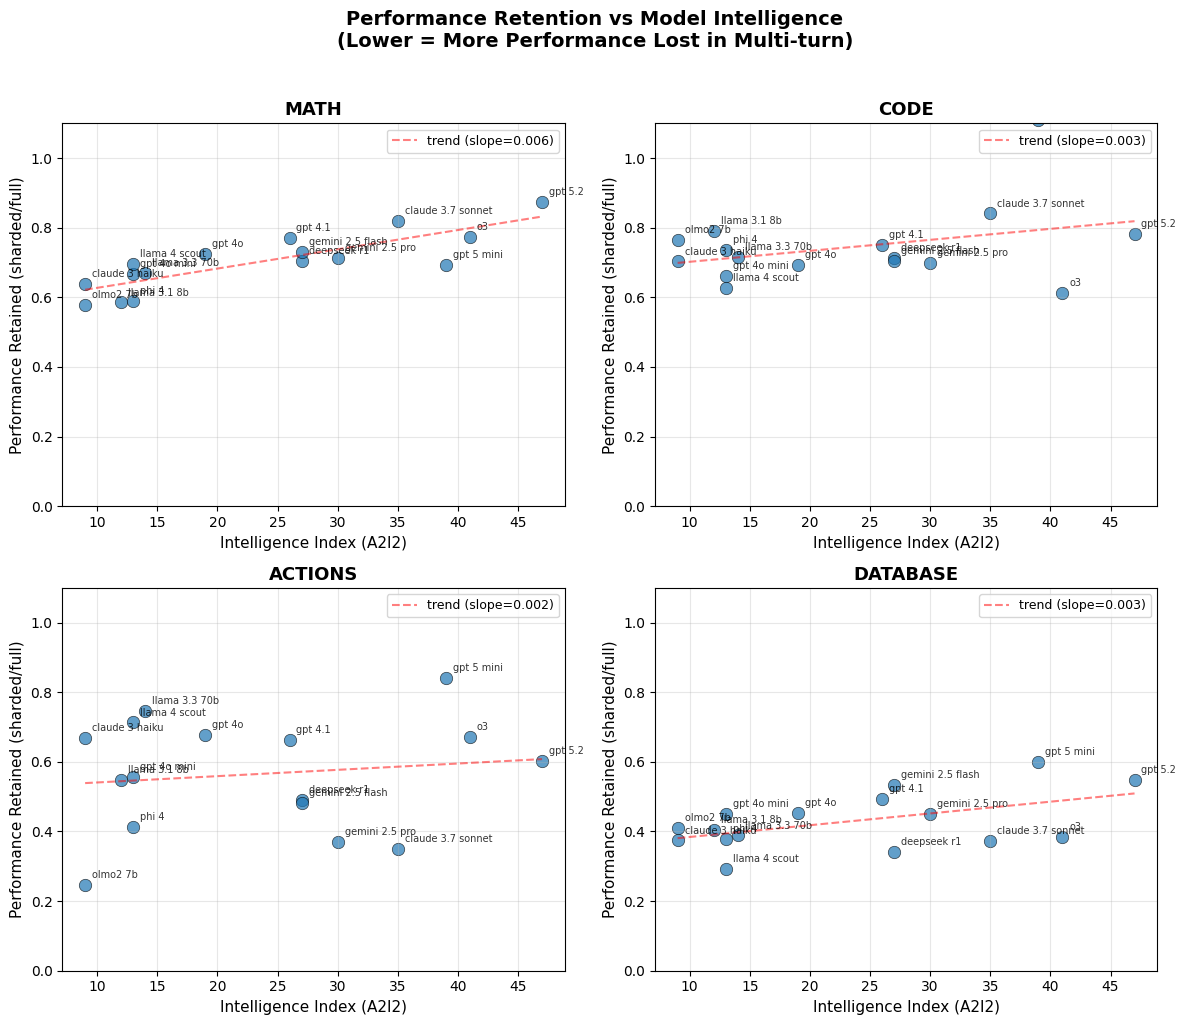

In [13]:
# Create 2x2 subplot figure for each task category
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df[df["task"] == task]
    
    # Plot scatter points
    ax.scatter(task_df["intelligence"], task_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add model labels
    for _, row in task_df.iterrows():
        ax.annotate(row["model"].replace("_", " "), 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line
    z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.suptitle("Performance Retention vs Model Intelligence\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence.png", dpi=150, bbox_inches='tight')
plt.show()

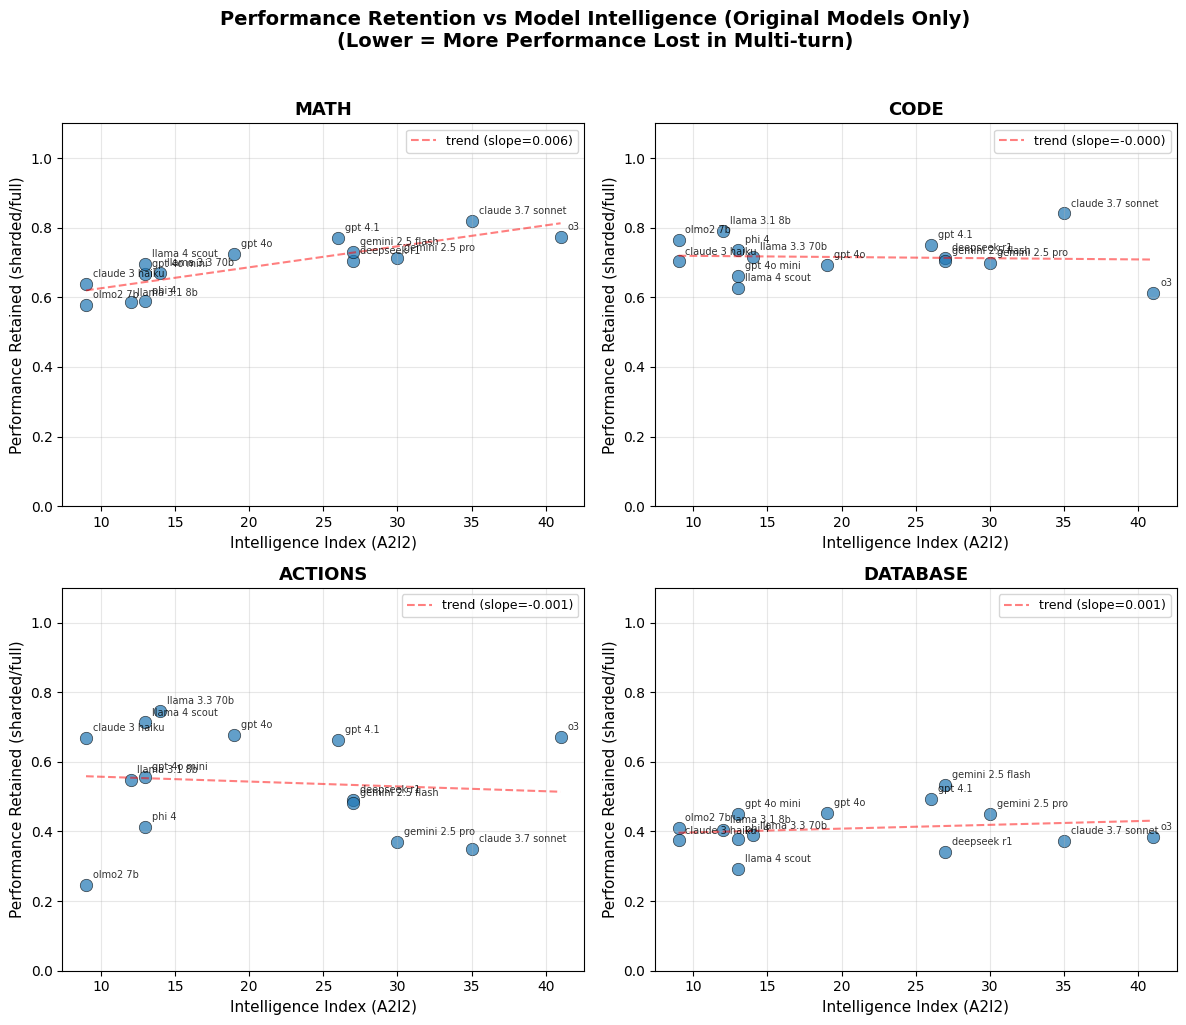

In [14]:
# Same plot WITHOUT ad-hoc additions (gpt_5_mini, gpt_5.2)
adhoc_models = {"gpt_5_mini", "gpt_5.2"}
df_original = df[~df["model"].isin(adhoc_models)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_original[df_original["task"] == task]
    
    # Plot scatter points
    ax.scatter(task_df["intelligence"], task_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add model labels
    for _, row in task_df.iterrows():
        ax.annotate(row["model"].replace("_", " "), 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line
    z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.suptitle("Performance Retention vs Model Intelligence (Original Models Only)\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence_original.png", dpi=150, bbox_inches='tight')
plt.show()